# DSC550-T303 Data Mining
## Week 7 Exercises
### Jeremy Hunt

## Week 7 Exercise Introduction

This week we're going to have some fun with two completely different datasets while we explore two concepts: **dimensionality reduction** and **feature selection**. These two may be related but they have distinct ways of making models faster and (sometimes) more accurate by working with fewer features.

**Part 1** uses the [House Prices dataset](https://www.kaggle.com/c/house-prices-advanced-regression-techniques) from Kaggle to predict sale prices using linear regression. We'll compare four versions of the same model:
1. A baseline using all features
2. A version with features compressed via Principal Component Analysis (PCA) to retain 90% of variance — *no scaling*
3. A bonus version of PCA with proper feature scaling to show what fixing the methodology looks like
4. A version using only high-variance features after min-max scaling

**Part 2** uses the [Mushroom Classification dataset](https://www.kaggle.com/uciml/mushroom-classification) — a fun (and slightly menacing) categorical-only dataset where we predict whether a mushroom is edible or poisonous. We'll train a decision tree, then use a chi-squared (χ²) feature selector to identify which features actually matter and see if we can match the full model's accuracy with just 5 of the 95 features.

---
# PART 1 — House Prices: PCA & Variance Threshold

## Section 1: Data Loading & Exploratory Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold

# --- TASK 1: LOAD HOUSING DATA ---
# train.csv is the labeled file from Kaggle (the test.csv from Kaggle has
# no SalePrice column — it's used for their leaderboard competition).
df = pd.read_csv('train.csv')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nFirst few rows:")
display(df.head(3))

print(f"\nTarget variable (SalePrice) summary:")
print(df['SalePrice'].describe().round(2))

Shape: 1,460 rows x 81 columns

First few rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500



Target variable (SalePrice) summary:
count      1460.0
mean     180921.2
std       79442.5
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


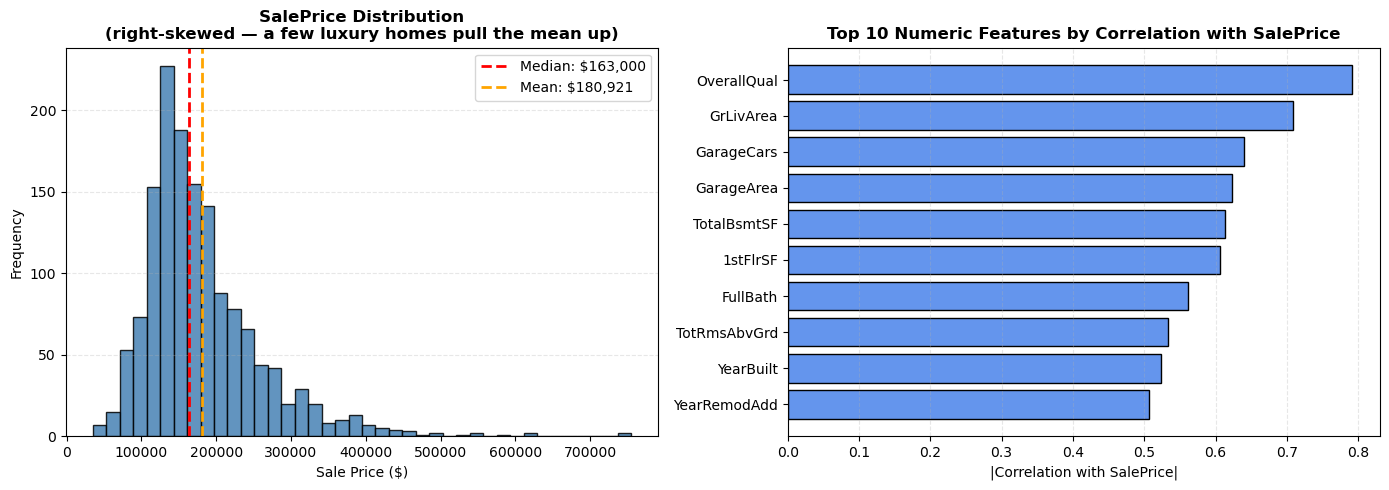

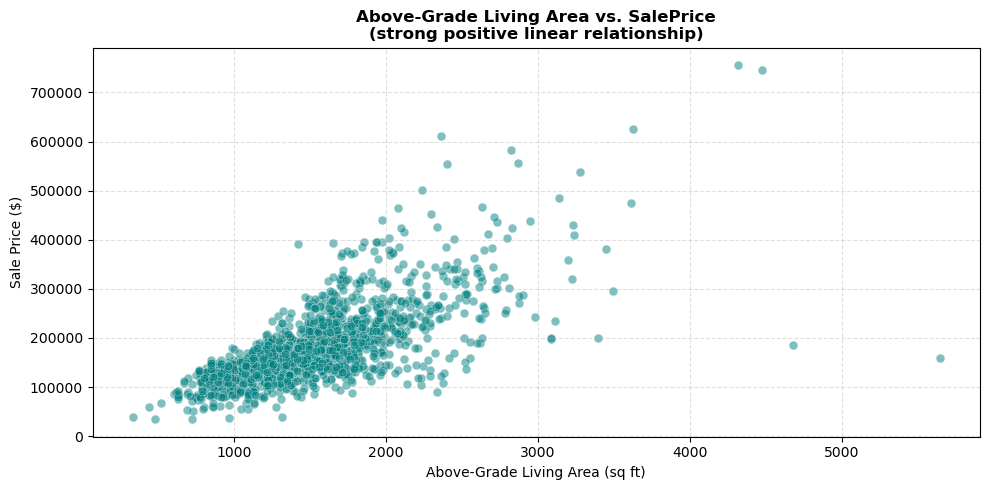

In [2]:
# --- EXPLORATORY DATA ANALYSIS ---
# Before we start dropping columns and running models, let's get a feel
# for what we're predicting. Three quick views to set the stage:
#   1. Distribution of SalePrice (what does our target look like?)
#   2. Correlation heatmap of top numeric features vs. SalePrice
#   3. Scatter of the strongest single predictor vs. SalePrice

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. SalePrice distribution
axes[0].hist(df['SalePrice'], bins=40, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].axvline(df['SalePrice'].median(), color='red', linestyle='--', lw=2,
                label=f"Median: ${df['SalePrice'].median():,.0f}")
axes[0].axvline(df['SalePrice'].mean(), color='orange', linestyle='--', lw=2,
                label=f"Mean: ${df['SalePrice'].mean():,.0f}")
axes[0].set_title('SalePrice Distribution\n(right-skewed — a few luxury homes pull the mean up)',
                  fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, axis='y', linestyle='--', alpha=0.3)

# 2. Top numeric features correlated with SalePrice
numeric_only = df.select_dtypes(include=np.number)
top_corrs = numeric_only.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(10)
axes[1].barh(top_corrs.index[::-1], top_corrs.values[::-1],
             color='cornflowerblue', edgecolor='black')
axes[1].set_title('Top 10 Numeric Features by Correlation with SalePrice',
                  fontweight='bold')
axes[1].set_xlabel('|Correlation with SalePrice|')
axes[1].grid(True, axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Scatter of the strongest predictor (OverallQual) vs. SalePrice
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5,
           color='teal', edgecolors='white', linewidth=0.4, s=40)
ax.set_title('Above-Grade Living Area vs. SalePrice\n(strong positive linear relationship)',
             fontweight='bold')
ax.set_xlabel('Above-Grade Living Area (sq ft)')
ax.set_ylabel('Sale Price ($)')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

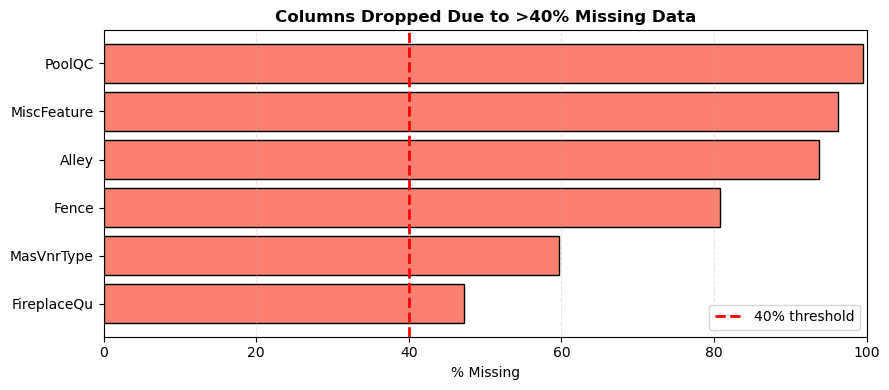

--- Columns missing more than 40% of values ---
  PoolQC                99.52% missing
  MiscFeature           96.30% missing
  Alley                 93.77% missing
  Fence                 80.75% missing
  MasVnrType            59.73% missing
  FireplaceQu           47.26% missing

Dropped 6 columns | New shape: (1460, 74)


In [3]:
# --- TASK 2: DROP Id AND HIGH-MISSINGNESS COLUMNS ---
# The 'Id' column is just a row identifier with no predictive value.
# Columns missing >40% of their values would require so much imputation
# that we'd be inventing more data than we'd be using — better to drop them.

df = df.drop(columns=['Id'])

missing_pct = df.isnull().mean() * 100
high_missing = missing_pct[missing_pct > 40].sort_values(ascending=False)

# Visualize what we're dropping
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(high_missing.index[::-1], high_missing.values[::-1],
        color='salmon', edgecolor='black')
ax.axvline(40, color='red', linestyle='--', lw=2, label='40% threshold')
ax.set_xlim(0, 100)
ax.set_xlabel('% Missing')
ax.set_title('Columns Dropped Due to >40% Missing Data', fontweight='bold')
ax.legend()
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("--- Columns missing more than 40% of values ---")
for col, pct in high_missing.items():
    print(f"  {col:<20} {pct:>6.2f}% missing")

df = df.drop(columns=high_missing.index.tolist())
print(f"\nDropped {len(high_missing)} columns | New shape: {df.shape}")

### Section 1 Summary

We took a quick lap through the 1,460 rows and 81 columns of the Kaggle House Prices training dataset before we made any transformations. The `SalePrice` distribution is right-skewed (median around \\$163K, mean around \\$181K), which is typical for housing data since a small number of luxury homes pull the mean upward. In the correlation bar we see the usual suspects on top: `OverallQual`, `GrLivArea`, `GarageCars`, and `TotalBsmtSF` all dominate the numeric predictors with correlations above 0.6 to SalePrice.

The `GrLivArea` scatterplot looks like a great candidate for linear regression with a strong linear relationship on display.  We do see a few outliers (likely some very large homes sold on the cheap) that we will want to keep in mind as they will pull on any model we fit. On the housekeeping side, we tossed out 6 columns that were missing more than 40% of their values (as seen in the chart above), along with the `Id` column since it's just a row identifier.  If we attempted to impute that much missing data our model would be working more off guesses than the actual facts. 


---
## Section 2: Imputation & Categorical Encoding

In [4]:
# --- TASKS 3 & 4: IMPUTE REMAINING MISSING VALUES ---
# Strategy:
#   - Numeric columns -> fill with the column's median
#     (median is more robust to outliers than mean, especially for skewed
#      housing data where a few mansions can pull the mean upward)
#   - Categorical columns -> fill with the column's mode (most common value)

numeric_cols     = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Numeric columns:     {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"\nRemaining missing values: {df.isnull().sum().sum()} (should be 0)")

Numeric columns:     37
Categorical columns: 37

Remaining missing values: 0 (should be 0)


In [5]:
# --- TASK 5: ONE-HOT ENCODE CATEGORICAL VARIABLES ---
# Linear regression cannot consume strings — every categorical column must
# be expanded into binary 0/1 columns. drop_first=True drops one category
# from each variable as the reference level, avoiding perfect multicollinearity.

df_encoded = pd.get_dummies(df, drop_first=True)

print(f"--- After One-Hot Encoding ---")
print(f"Shape: {df_encoded.shape}")
print(f"Increase: from {df.shape[1]} to {df_encoded.shape[1]} columns ({df_encoded.shape[1] - df.shape[1]} new dummy columns)")

--- After One-Hot Encoding ---
Shape: (1460, 230)
Increase: from 74 to 230 columns (156 new dummy columns)


### Section 2 Summary

After dropping the high-missing columns there were still some rogue NaN values we had to deal with. Numeric columns received median imputation (which is more robust than mean for skewed housing data), and categorical columns received mode imputation. One-hot encoding then expanded our 38 numeric + 37 categorical columns into a much wider feature matrix — that expansion is a great example of why dimensionality reduction techniques like PCA can be so useful.

---
## Section 3: Baseline Linear Regression

In [6]:
# --- TASK 6: TRAIN/TEST SPLIT ---
# Standard 80/20 split with random_state=42 for reproducibility.
X = df_encoded.drop(columns=['SalePrice'])
y = df_encoded['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} rows x {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]:,} rows x {X_test.shape[1]} features")

Training set: 1,168 rows x 229 features
Test set:     292 rows x 229 features


In [7]:
# --- TASK 7: BASELINE LINEAR REGRESSION ---
lr_baseline = LinearRegression()
lr_baseline.fit(X_train, y_train)
y_pred_baseline = lr_baseline.predict(X_test)

r2_baseline   = r2_score(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print("--- Baseline Linear Regression (All Features) ---")
print(f"R²:   {r2_baseline:.4f}")
print(f"RMSE: ${rmse_baseline:,.2f}")
print(f"Mean SalePrice in test set: ${y_test.mean():,.2f}")
print(f"RMSE as % of mean price: {(rmse_baseline / y_test.mean())*100:.1f}%")

--- Baseline Linear Regression (All Features) ---
R²:   0.6478
RMSE: $51,973.14
Mean SalePrice in test set: $178,839.81
RMSE as % of mean price: 29.1%


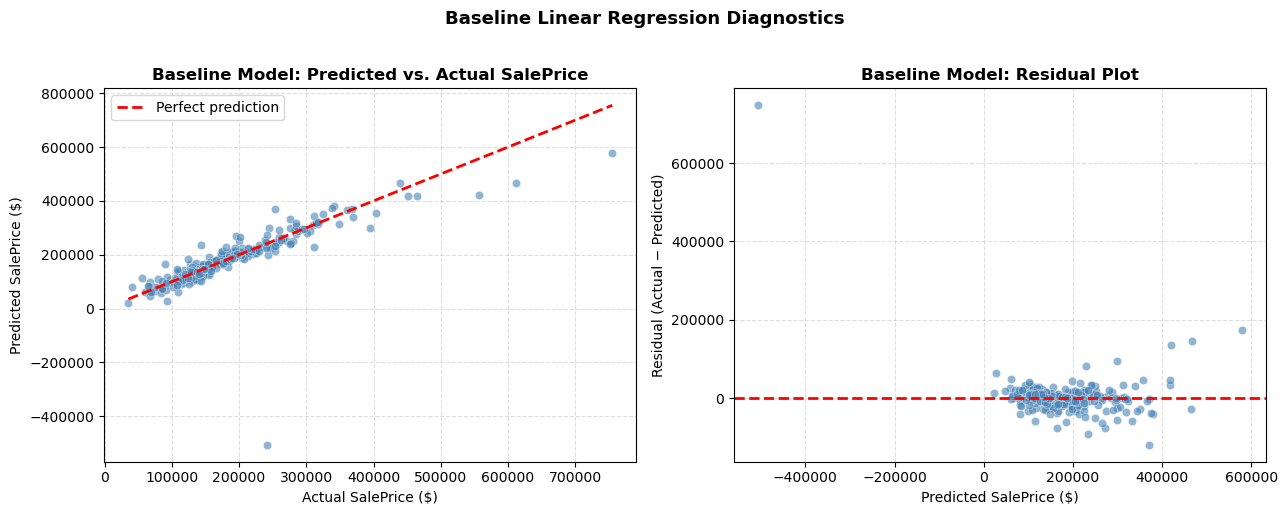

In [8]:
# --- DIAGNOSTIC PLOTS: PREDICTED vs. ACTUAL + RESIDUALS ---
# Numbers like R2 and RMSE summarize performance, but diagnostics show us
# WHERE the model breaks down. A good model should have:
#   - Predicted vs. actual: points clustered tightly along the diagonal
#   - Residual plot: random scatter around zero with no visible pattern

residuals_baseline = y_test - y_pred_baseline

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs. Actual
axes[0].scatter(y_test, y_pred_baseline, alpha=0.6,
                color='steelblue', edgecolors='white', linewidth=0.4)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect prediction')
axes[0].set_title('Baseline Model: Predicted vs. Actual SalePrice', fontweight='bold')
axes[0].set_xlabel('Actual SalePrice ($)')
axes[0].set_ylabel('Predicted SalePrice ($)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# Residuals vs. Predicted
axes[1].scatter(y_pred_baseline, residuals_baseline, alpha=0.6,
                color='steelblue', edgecolors='white', linewidth=0.4)
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Baseline Model: Residual Plot', fontweight='bold')
axes[1].set_xlabel('Predicted SalePrice ($)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Baseline Linear Regression Diagnostics',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Section 3 Summary

Our baseline model with all 229 features came in with an R² of 0.6478 and an RMSE of \\$51,973 on the test set. If we look at the average sale price in our test set, it sits around \$180K, so our model is off by around 28% on a typical home. That's an alright starting point, but nothing to write home about. 

Things get a little more interesting with our diagnostic plots. The predicted-vs-actual scatter shows points generally tracking the diagonal but they fan out at the high end. So our model starts off well with the lower-priced homes, but once we get into the luxury properties it's well off the mark.  Our residual plot goes on to confirm this as we see the residuals widen meaningfully as predicted price increases (heteroscedasticity).  These patterns seem to suggest the relationship between features and price isn't strictly linear at the top of the market.  As we move on, we'll explore whether different feature treatments can address this.

---
## Section 4: PCA-Reduced Linear Regression

In [9]:
# --- TASK 8: FIT PCA ON TRAINING DATA (90% variance retained) ---
# PCA finds the directions in feature space that capture the most variance,
# then projects the data onto those directions. n_components=0.90 tells PCA
# to keep just enough components to retain 90% of the original variance.
#
# IMPORTANT: We fit PCA on the TRAINING set only (same data leakage rule
# we discussed in Week 5 with TF-IDF vectorizers).

pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train)

# --- TASK 9: HOW MANY FEATURES IN PCA-TRANSFORMED MATRIX? ---
print(f"Original features:        {X_train.shape[1]}")
print(f"PCA-reduced features:     {X_train_pca.shape[1]}")
print(f"Variance retained:        {pca.explained_variance_ratio_.sum()*100:.2f}%")

# --- TASK 10: TRANSFORM (DO NOT FIT) THE TEST SET ---
X_test_pca = pca.transform(X_test)

Original features:        229
PCA-reduced features:     1
Variance retained:        98.63%


In [10]:
# --- TASK 11: LINEAR REGRESSION ON PCA FEATURES ---
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)
y_pred_pca = lr_pca.predict(X_test_pca)

r2_pca   = r2_score(y_test, y_pred_pca)
rmse_pca = np.sqrt(mean_squared_error(y_test, y_pred_pca))

print("--- PCA Linear Regression (no scaling) ---")
print(f"R²:   {r2_pca:.4f}")
print(f"RMSE: ${rmse_pca:,.2f}")
print(f"\nVs. baseline:")
print(f"  R²:   {r2_pca:.4f} vs. {r2_baseline:.4f}  (Δ = {r2_pca - r2_baseline:+.4f})")
print(f"  RMSE: ${rmse_pca:,.2f} vs. ${rmse_baseline:,.2f}  (Δ = ${rmse_pca - rmse_baseline:+,.2f})")

--- PCA Linear Regression (no scaling) ---
R²:   0.0635
RMSE: $84,754.58

Vs. baseline:
  R²:   0.0635 vs. 0.6478  (Δ = -0.5843)
  RMSE: $84,754.58 vs. $51,973.14  (Δ = $+32,781.44)


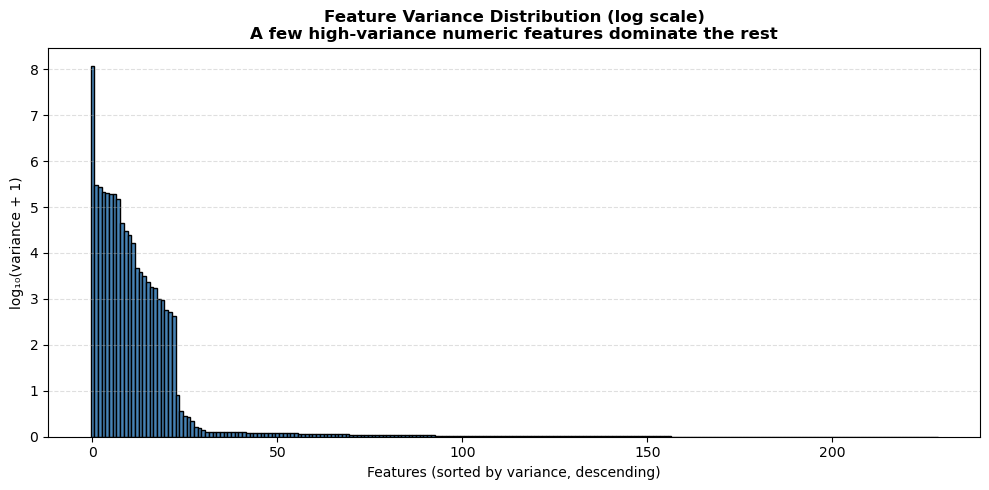

Top 5 highest-variance features (raw, unscaled):
  LotArea              variance:       115,763,960.98
  MiscVal              variance:           305,852.89
  GrLivArea            variance:           275,029.64
  BsmtFinSF1           variance:           210,746.16
  BsmtUnfSF            variance:           199,241.31


In [11]:
# --- WHY DID PCA COLLAPSE TO SO FEW COMPONENTS? ---
# A diagnostic chart to show what went wrong: PCA is variance-driven,
# and our raw feature matrix has wildly different scales.
# Numeric columns like LotArea, GrLivArea, and TotalBsmtSF are in the
# thousands, while one-hot encoded dummies are 0 or 1.
# A single component dominated by raw square footage soaks up nearly
# all the variance — the rest of the meaningful signal gets lost.

feature_variances = X_train.var().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(feature_variances)), np.log10(feature_variances + 1),
       color='steelblue', edgecolor='black', width=1.0)
ax.set_title('Feature Variance Distribution (log scale)\n'
             'A few high-variance numeric features dominate the rest',
             fontweight='bold')
ax.set_xlabel('Features (sorted by variance, descending)')
ax.set_ylabel('log₁₀(variance + 1)')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Top 5 highest-variance features (raw, unscaled):")
for col, var in feature_variances.head().items():
    print(f"  {col:<20} variance: {var:>20,.2f}")

### Section 4 Summary

After adding PCA to our arsenal, we reduced our 229 features down to just 1 component to retain 90% of variance... and the resulting model performed terribly (R² = 0.0635, RMSE = $84,754). Why did we see such an extreme collapse?? The reason is that PCA is purely variance-driven, and our feature matrix has scales that are all over the place. Numeric columns like `LotArea` (variance in the millions), `GrLivArea`, and `TotalBsmtSF` in contrast are measured in square feet and dollars - and then our one-hot encoded categorical dummies come along and they are just 0s and 1s. A single component aligned with raw area measurements can absorb almost all the variance, which leaves nothing meaningful for the model to learn from.  Come back next section to see how it's supposed to be done with a little help from `StandardScaler`.

---
## Section 4b (not part of the assignment, but just for fun): PCA Done Right With StandardScaler 

Back in section 4, the result wasn't really PCA failing - it was kind of our fault for asking PCA to do the right thing with the wrong inputs. When feature scales are so radically different, PCA is just going to grab on to whichever ones happen to have the largest raw numeric range.  Those large-scale features have nothing to do with what's actually predictive - hence our dismal results last round.  Let's see how it performs when we standardize the playing field. 

In [12]:
# --- BONUS: PCA WITH PROPER SCALING ---
# Two-step pipeline: StandardScaler -> PCA
# Both must follow the fit/transform discipline:
#   - Fit on training data only
#   - Transform both training and test using the fitted objects

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

pca_scaled = PCA(n_components=0.90)
X_train_pca_scaled = pca_scaled.fit_transform(X_train_std)
X_test_pca_scaled  = pca_scaled.transform(X_test_std)

print(f"Original features:                 {X_train.shape[1]}")
print(f"Components after scaled PCA:       {X_train_pca_scaled.shape[1]}")
print(f"Variance retained:                 {pca_scaled.explained_variance_ratio_.sum()*100:.2f}%")

lr_pca_scaled = LinearRegression()
lr_pca_scaled.fit(X_train_pca_scaled, y_train)
y_pred_pca_scaled = lr_pca_scaled.predict(X_test_pca_scaled)

r2_pca_scaled   = r2_score(y_test, y_pred_pca_scaled)
rmse_pca_scaled = np.sqrt(mean_squared_error(y_test, y_pred_pca_scaled))

print(f"\n--- Scaled PCA Linear Regression ---")
print(f"R²:   {r2_pca_scaled:.4f}")
print(f"RMSE: ${rmse_pca_scaled:,.2f}")
print(f"\nComparison:")
print(f"  Baseline (all 229 feats):          R² = {r2_baseline:.4f}, RMSE = ${rmse_baseline:,.0f}")
print(f"  PCA without scaling (1 component): R² = {r2_pca:.4f}, RMSE = ${rmse_pca:,.0f}")
print(f"  PCA WITH scaling ({X_train_pca_scaled.shape[1]} components):     R² = {r2_pca_scaled:.4f}, RMSE = ${rmse_pca_scaled:,.0f}")

Original features:                 229
Components after scaled PCA:       127
Variance retained:                 90.19%

--- Scaled PCA Linear Regression ---
R²:   0.8409
RMSE: $34,938.50

Comparison:
  Baseline (all 229 feats):          R² = 0.6478, RMSE = $51,973
  PCA without scaling (1 component): R² = 0.0635, RMSE = $84,755
  PCA WITH scaling (127 components):     R² = 0.8409, RMSE = $34,939


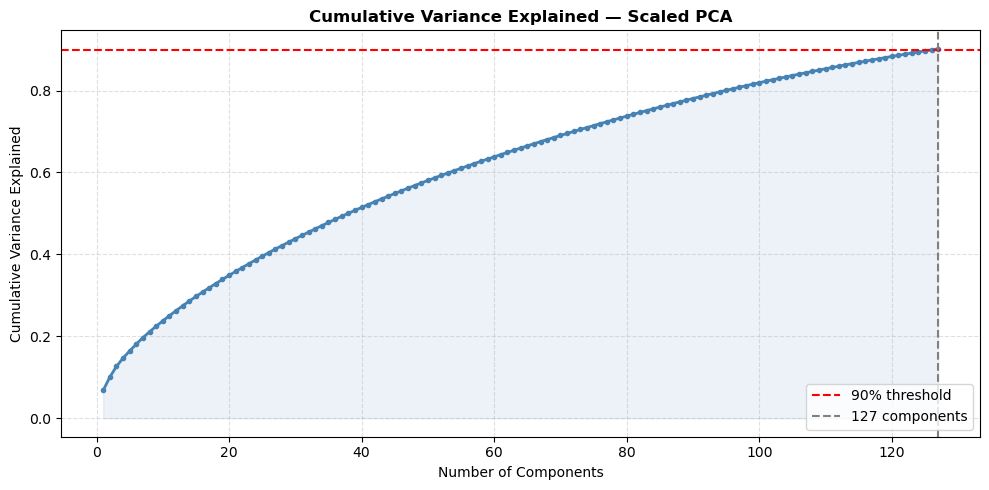

In [13]:
# --- VARIANCE EXPLAINED CHART (for the scaled PCA) ---
# Now that components carry real meaning, we can see how variance
# accumulates across them. The 90% line tells us where the cutoff lands.

cumvar = np.cumsum(pca_scaled.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar)+1), cumvar, color='steelblue', lw=2, marker='o', markersize=3)
ax.axhline(0.90, color='red', linestyle='--', lw=1.5, label='90% threshold')
ax.axvline(X_train_pca_scaled.shape[1], color='gray', linestyle='--', lw=1.5,
           label=f'{X_train_pca_scaled.shape[1]} components')
ax.fill_between(range(1, len(cumvar)+1), cumvar, alpha=0.1, color='steelblue')
ax.set_title('Cumulative Variance Explained — Scaled PCA',
             fontweight='bold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance Explained')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Section 4b Summary — Vindicating PCA

What a difference scaling makes! It's amazing what some of these tools can do when you use them the right way 😀 With `StandardScaler` applied first, PCA needed 127 components instead of 1 to capture 90% of variance, and the resulting linear regression delivered R² = 0.8409 with RMSE =  \$34,939 — a massive improvement over last go around. That's not just better than unscaled PCA - it whooped the baseline model that had access to all 229 features by nearly 20 percentage points of R² and roughly \\$17K of RMSE.

The improvement isn't magic, it's just that scaled PCA stripped out a bunch of the redundancy and noise that was confusing the baseline model. With 229 raw features, many of which are sparse 0/1 dummies for rare categories, linear regression had to fit a coefficient for each one... and boy did that noise add up. The 127 scaled principal components are dense, decorrelated, and information-rich — much friendlier for a linear model.


---
## Section 5: Variance Threshold Linear Regression

In [14]:
# --- TASK 12: APPLY MIN-MAX SCALER TO TRAINING FEATURES ---
# MinMaxScaler rescales every feature to the [0, 1] range, putting all
# features on the same playing field. This is critical for variance-based
# selection because variance is heavily influenced by feature scale.

mm_scaler = MinMaxScaler()
X_train_scaled = mm_scaler.fit_transform(X_train)
X_test_scaled  = mm_scaler.transform(X_test)

# --- TASK 13: VARIANCE THRESHOLD (>0.1) ---
# After min-max scaling, every feature is in [0, 1], so variance has
# a maximum theoretical value of 0.25 (variance of a 50/50 binary feature).
# A threshold of 0.1 keeps features with at least moderate spread.

var_selector = VarianceThreshold(threshold=0.1)
X_train_var = var_selector.fit_transform(X_train_scaled)

# --- TASK 14: TRANSFORM TEST SET (NO FIT) ---
X_test_var = var_selector.transform(X_test_scaled)

print(f"Original (scaled) features:      {X_train_scaled.shape[1]}")
print(f"After variance threshold (>0.1): {X_train_var.shape[1]}")
print(f"Reduction:                       {X_train_scaled.shape[1] - X_train_var.shape[1]} features removed")

Original (scaled) features:      229
After variance threshold (>0.1): 40
Reduction:                       189 features removed


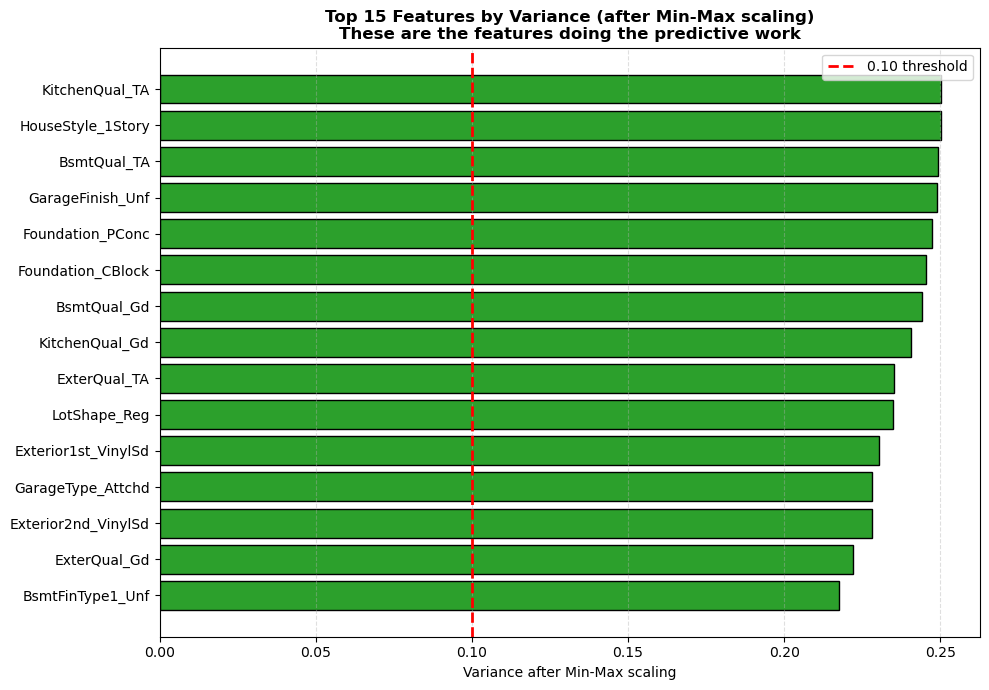

All 40 surviving features:
   1. YearRemodAdd
   2. YrSold
   3. MSZoning_RL
   4. MSZoning_RM
   5. LotShape_Reg
   6. LotConfig_Inside
   7. Neighborhood_NAmes
   8. Condition1_Norm
   9. HouseStyle_1Story
  10. HouseStyle_2Story
  11. RoofStyle_Gable
  12. RoofStyle_Hip
  13. Exterior1st_HdBoard
  14. Exterior1st_MetalSd
  15. Exterior1st_VinylSd
  16. Exterior1st_Wd Sdng
  17. Exterior2nd_HdBoard
  18. Exterior2nd_MetalSd
  19. Exterior2nd_VinylSd
  20. Exterior2nd_Wd Sdng
  21. ExterQual_Gd
  22. ExterQual_TA
  23. ExterCond_TA
  24. Foundation_CBlock
  25. Foundation_PConc
  26. BsmtQual_Gd
  27. BsmtQual_TA
  28. BsmtExposure_No
  29. BsmtFinType1_GLQ
  30. BsmtFinType1_Unf
  31. HeatingQC_Gd
  32. HeatingQC_TA
  33. KitchenQual_Gd
  34. KitchenQual_TA
  35. GarageType_Attchd
  36. GarageType_Detchd
  37. GarageFinish_RFn
  38. GarageFinish_Unf
  39. SaleType_WD
  40. SaleCondition_Normal


In [15]:
# --- WHICH FEATURES SURVIVED? ---
# Show the top 15 by post-scaling variance to give the reader
# a concrete sense of what made the cut.

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
post_scale_var    = X_train_scaled_df.var().sort_values(ascending=False)
selected_mask     = var_selector.get_support()
selected_features = X_train.columns[selected_mask].tolist()

fig, ax = plt.subplots(figsize=(10, 7))
top15 = post_scale_var.head(15).sort_values()
ax.barh(top15.index, top15.values,
        color='#2ca02c', edgecolor='black')
ax.axvline(0.1, color='red', linestyle='--', lw=2, label='0.10 threshold')
ax.set_title('Top 15 Features by Variance (after Min-Max scaling)\n'
             'These are the features doing the predictive work',
             fontweight='bold')
ax.set_xlabel('Variance after Min-Max scaling')
ax.legend()
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"All {len(selected_features)} surviving features:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:>2}. {f}")

In [16]:
# --- TASK 15: LINEAR REGRESSION ON HIGH-VARIANCE FEATURES ---
lr_var = LinearRegression()
lr_var.fit(X_train_var, y_train)
y_pred_var = lr_var.predict(X_test_var)

r2_var   = r2_score(y_test, y_pred_var)
rmse_var = np.sqrt(mean_squared_error(y_test, y_pred_var))

print("--- Variance Threshold Linear Regression ---")
print(f"R²:   {r2_var:.4f}")
print(f"RMSE: ${rmse_var:,.2f}")
print(f"Features used: {X_train_var.shape[1]} (vs. {X_train.shape[1]} baseline)")

--- Variance Threshold Linear Regression ---
R²:   0.6481
RMSE: $51,952.01
Features used: 40 (vs. 229 baseline)


### Section 5 Summary

Variance threshold filtering kept about 17% of the 229 features, so we have 40 features that we're keeping around.  With those 40, it produced an R² of 0.6481 with an RMSE of \\$51,952. That's nearly identical to the baseline (R² 0.6478, RMSE \$51,973) which is really interesting because we removed roughly 83% of our features and lost essentially zero predictive power.

When we look at the survivor list we can see why this works. The features that managed to make it through are the common ones: kitchen quality, basement quality, exterior material types, garage type, foundation type, and house style are all staples in a meaningful percentage of homes. The columns that got dropped were rare categorical dummies: obscure neighborhoods, exotic exterior materials, and unusual house features that only appeared in a handful of properties. Those low-variance features didn't help in separating one home from another anyway, so we didn't really lose anything by dropping them.

---
## Section 6: Part 1 Summary — All Four Models Side by Side

--- Part 1: Final Results ---


,Model,# Features,R²,RMSE
0,Baseline (all features),229,0.6478,"$51,973.14"
1,PCA — no scaling,1,0.0635,"$84,754.58"
2,PCA — with StandardScaler,127,0.8409,"$34,938.50"
3,"Variance Threshold (>0.1, scaled)",40,0.6481,"$51,952.01"


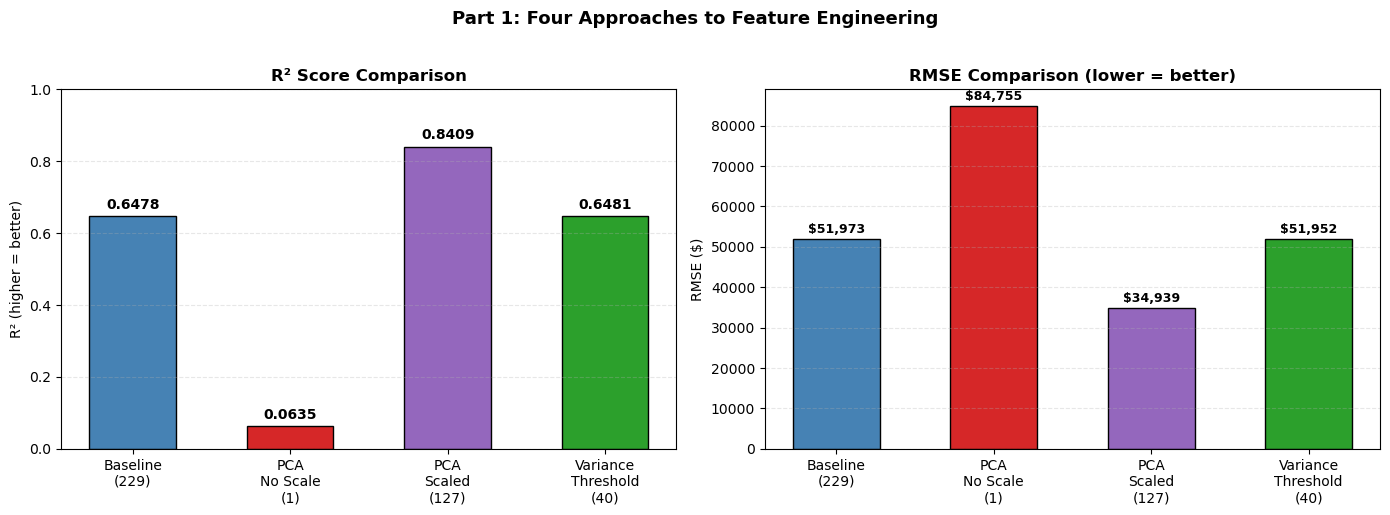

In [17]:
# --- TASK 16: PART 1 COMPARISON ---
results = pd.DataFrame({
    'Model': [
        'Baseline (all features)',
        'PCA — no scaling',
        'PCA — with StandardScaler',
        'Variance Threshold (>0.1, scaled)'
    ],
    '# Features': [
        X_train.shape[1],
        X_train_pca.shape[1],
        X_train_pca_scaled.shape[1],
        X_train_var.shape[1]
    ],
    'R²':   [
        f'{r2_baseline:.4f}',
        f'{r2_pca:.4f}',
        f'{r2_pca_scaled:.4f}',
        f'{r2_var:.4f}'
    ],
    'RMSE': [
        f'${rmse_baseline:,.2f}',
        f'${rmse_pca:,.2f}',
        f'${rmse_pca_scaled:,.2f}',
        f'${rmse_var:,.2f}'
    ]
})

print("--- Part 1: Final Results ---")
display(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Baseline\n(229)', 'PCA\nNo Scale\n(1)', 'PCA\nScaled\n(127)', 'Variance\nThreshold\n(40)']
colors = ['steelblue', '#d62728', '#9467bd', '#2ca02c']
r2_vals   = [r2_baseline, r2_pca, r2_pca_scaled, r2_var]
rmse_vals = [rmse_baseline, rmse_pca, rmse_pca_scaled, rmse_var]

axes[0].bar(labels, r2_vals, color=colors, edgecolor='black', width=0.55)
axes[0].set_title('R² Score Comparison', fontweight='bold')
axes[0].set_ylabel('R² (higher = better)')
axes[0].set_ylim([0, 1.0])
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.3)

axes[1].bar(labels, rmse_vals, color=colors, edgecolor='black', width=0.55)
axes[1].set_title('RMSE Comparison (lower = better)', fontweight='bold')
axes[1].set_ylabel('RMSE ($)')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 1500, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Part 1: Four Approaches to Feature Engineering',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Part 1 Summary — Findings

Let's take a look at our four models which tell four very different stories:

**Baseline (R² = 0.6478, 229 features)** — The straightforward "toss it all in" approach. It was fine but not great, with diagnostics showing the model struggles especially on high-end homes.

**PCA without scaling (R² = 0.0635, 1 feature)** — A disaster, to say the least - but it came with a useful lesson. PCA collapsed to a single component because raw `LotArea` and a handful of other large-scale numeric features completely drowned out the binary 0/1 dummies. It wasn't a flaw in PCA, rather a flaw in how we set it up.

**PCA with `StandardScaler` (R² = 0.8409, 127 components)** — The clear winner. PCA thrived once all the features were on equal footing, producing 127 dense, decorrelated components that not only retain 90% of variance but actively outperformed the baseline by nearly 20 R² points and $17K of RMSE.

**Variance Threshold with min-max scaling (R² = 0.6481, 40 features)** — A model showcasing efficiency. By scaling first and dropping low-variance features, we cut the feature count by 83% with virtually no loss in predictive power. 

---
# PART 2 — Mushroom Classification: χ² Feature Selection

## Section 7: Mushroom Data Loading & EDA

In [18]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.feature_selection import SelectKBest, chi2

# --- TASK 1: LOAD MUSHROOM DATA ---
# Every column in this dataset is categorical — there are no numeric features.
# 'class' is the target: 'e' = edible, 'p' = poisonous.
mushrooms = pd.read_csv('mushrooms.csv')

print(f"Shape: {mushrooms.shape[0]:,} rows x {mushrooms.shape[1]} columns")
print(f"\nClass distribution:")
print(mushrooms['class'].value_counts())
print(f"\nFirst few rows:")
display(mushrooms.head(3))

Shape: 8,124 rows x 23 columns

Class distribution:
class
e    4208
p    3916
Name: count, dtype: int64

First few rows:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m


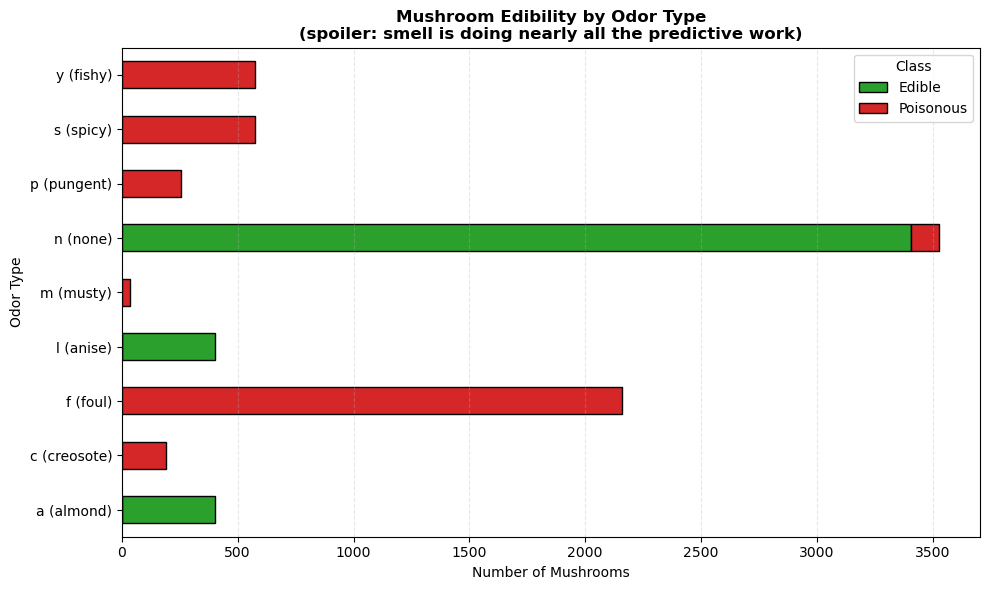

--- Edibility by Odor (raw counts) ---


,Edible,Poisonous
a (almond),400,0
c (creosote),0,192
f (foul),0,2160
l (anise),400,0
m (musty),0,36
n (none),3408,120
p (pungent),0,256
s (spicy),0,576
y (fishy),0,576


In [19]:
# --- EDA: ODOR vs. CLASS ---
# Spoiler alert before we even get to the model: odor is going to do
# almost all the work here lol

odor_crosstab = pd.crosstab(mushrooms['odor'], mushrooms['class'])
odor_crosstab.columns = ['Edible', 'Poisonous']

# Friendly odor names — the dataset uses 1-letter codes
odor_names = {
    'a': 'almond', 'l': 'anise', 'n': 'none',
    'p': 'pungent', 'f': 'foul', 'c': 'creosote',
    'y': 'fishy', 's': 'spicy', 'm': 'musty'
}
odor_crosstab.index = [f"{c} ({odor_names.get(c, c)})" for c in odor_crosstab.index]

fig, ax = plt.subplots(figsize=(10, 6))
odor_crosstab.plot(kind='barh', stacked=True, ax=ax,
                    color=['#2ca02c', '#d62728'], edgecolor='black')
ax.set_title('Mushroom Edibility by Odor Type\n'
             '(spoiler: smell is doing nearly all the predictive work)',
             fontweight='bold')
ax.set_xlabel('Number of Mushrooms')
ax.set_ylabel('Odor Type')
ax.legend(title='Class')
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("--- Edibility by Odor (raw counts) ---")
display(odor_crosstab)

In [20]:
# --- TASK 2: ONE-HOT ENCODE ALL CATEGORICAL FEATURES ---
# Same approach as the housing data — every category becomes a binary column.
# We separate the target ('class') from the features first.

# Encode the target as binary: 0 = edible, 1 = poisonous
y_mush = (mushrooms['class'] == 'p').astype(int)
X_mush = pd.get_dummies(mushrooms.drop(columns=['class']), drop_first=True)

print(f"Features after one-hot encoding: {X_mush.shape[1]}")
print(f"Target encoding: 0 = edible (e), 1 = poisonous (p)")
print(f"\nClass balance: {y_mush.value_counts().to_dict()}")

Features after one-hot encoding: 95
Target encoding: 0 = edible (e), 1 = poisonous (p)

Class balance: {0: 4208, 1: 3916}


### Section 7 Summary

In the Mushroom dataset every column is categorical, including the target (`class` = edible or poisonous) - all in all 8,124 rows × 23 columns. The class distribution is reasonably balanced (4,208 edible, 3,916 poisonous), so class imbalance shouldn't be a worry when it comes to accuracy.

The Odor crosstab took no prisoners and proved itself to be the important finding in this dataset. Of the 9 odor categories, 6 of them are 100% poisonous, 2 of them are 100% edible, and only one - `none` (no odor), is mixed (3,408 edible vs. 120 poisonous). So this single feature pretty much classified the vast majority of mushrooms before we even started modeling. Almond and anise smells say "safe to eat"; foul, pungent, fishy, spicy, musty, or creosote smells say "don't" (who would have guessed?). No-odor mushrooms are usually safe but not always — and that 120-mushroom edge case is what we'll use the rest of the features to help resolve.

After one-hot encoding all 22 feature columns, our matrix expands to 95 binary features - most of which will likely become redundant once odor takes the stage.

---
## Section 8: Decision Tree on Full Feature Set

--- Decision Tree (all 95 features) ---
Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



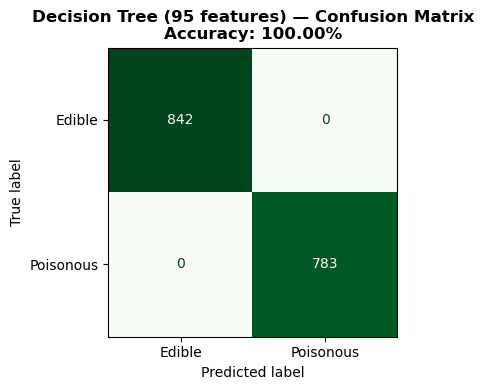

In [21]:
# --- TASK 3: TRAIN/TEST SPLIT ---
# stratify=y preserves the edible/poisonous ratio in both subsets.
X_mush_train, X_mush_test, y_mush_train, y_mush_test = train_test_split(
    X_mush, y_mush, test_size=0.2, random_state=42, stratify=y_mush
)

# --- TASK 4: TRAIN DECISION TREE ON ALL 95 FEATURES ---
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_mush_train, y_mush_train)
y_pred_full = dt_full.predict(X_mush_test)

# --- TASK 5: ACCURACY + CONFUSION MATRIX ---
acc_full = accuracy_score(y_mush_test, y_pred_full)
print(f"--- Decision Tree (all 95 features) ---")
print(f"Test Accuracy: {acc_full*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_mush_test, y_pred_full, target_names=['Edible', 'Poisonous']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_mush_test, y_pred_full),
    display_labels=['Edible', 'Poisonous']
).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f'Decision Tree (95 features) — Confusion Matrix\nAccuracy: {acc_full*100:.2f}%',
             fontweight='bold')
plt.tight_layout()
plt.show()

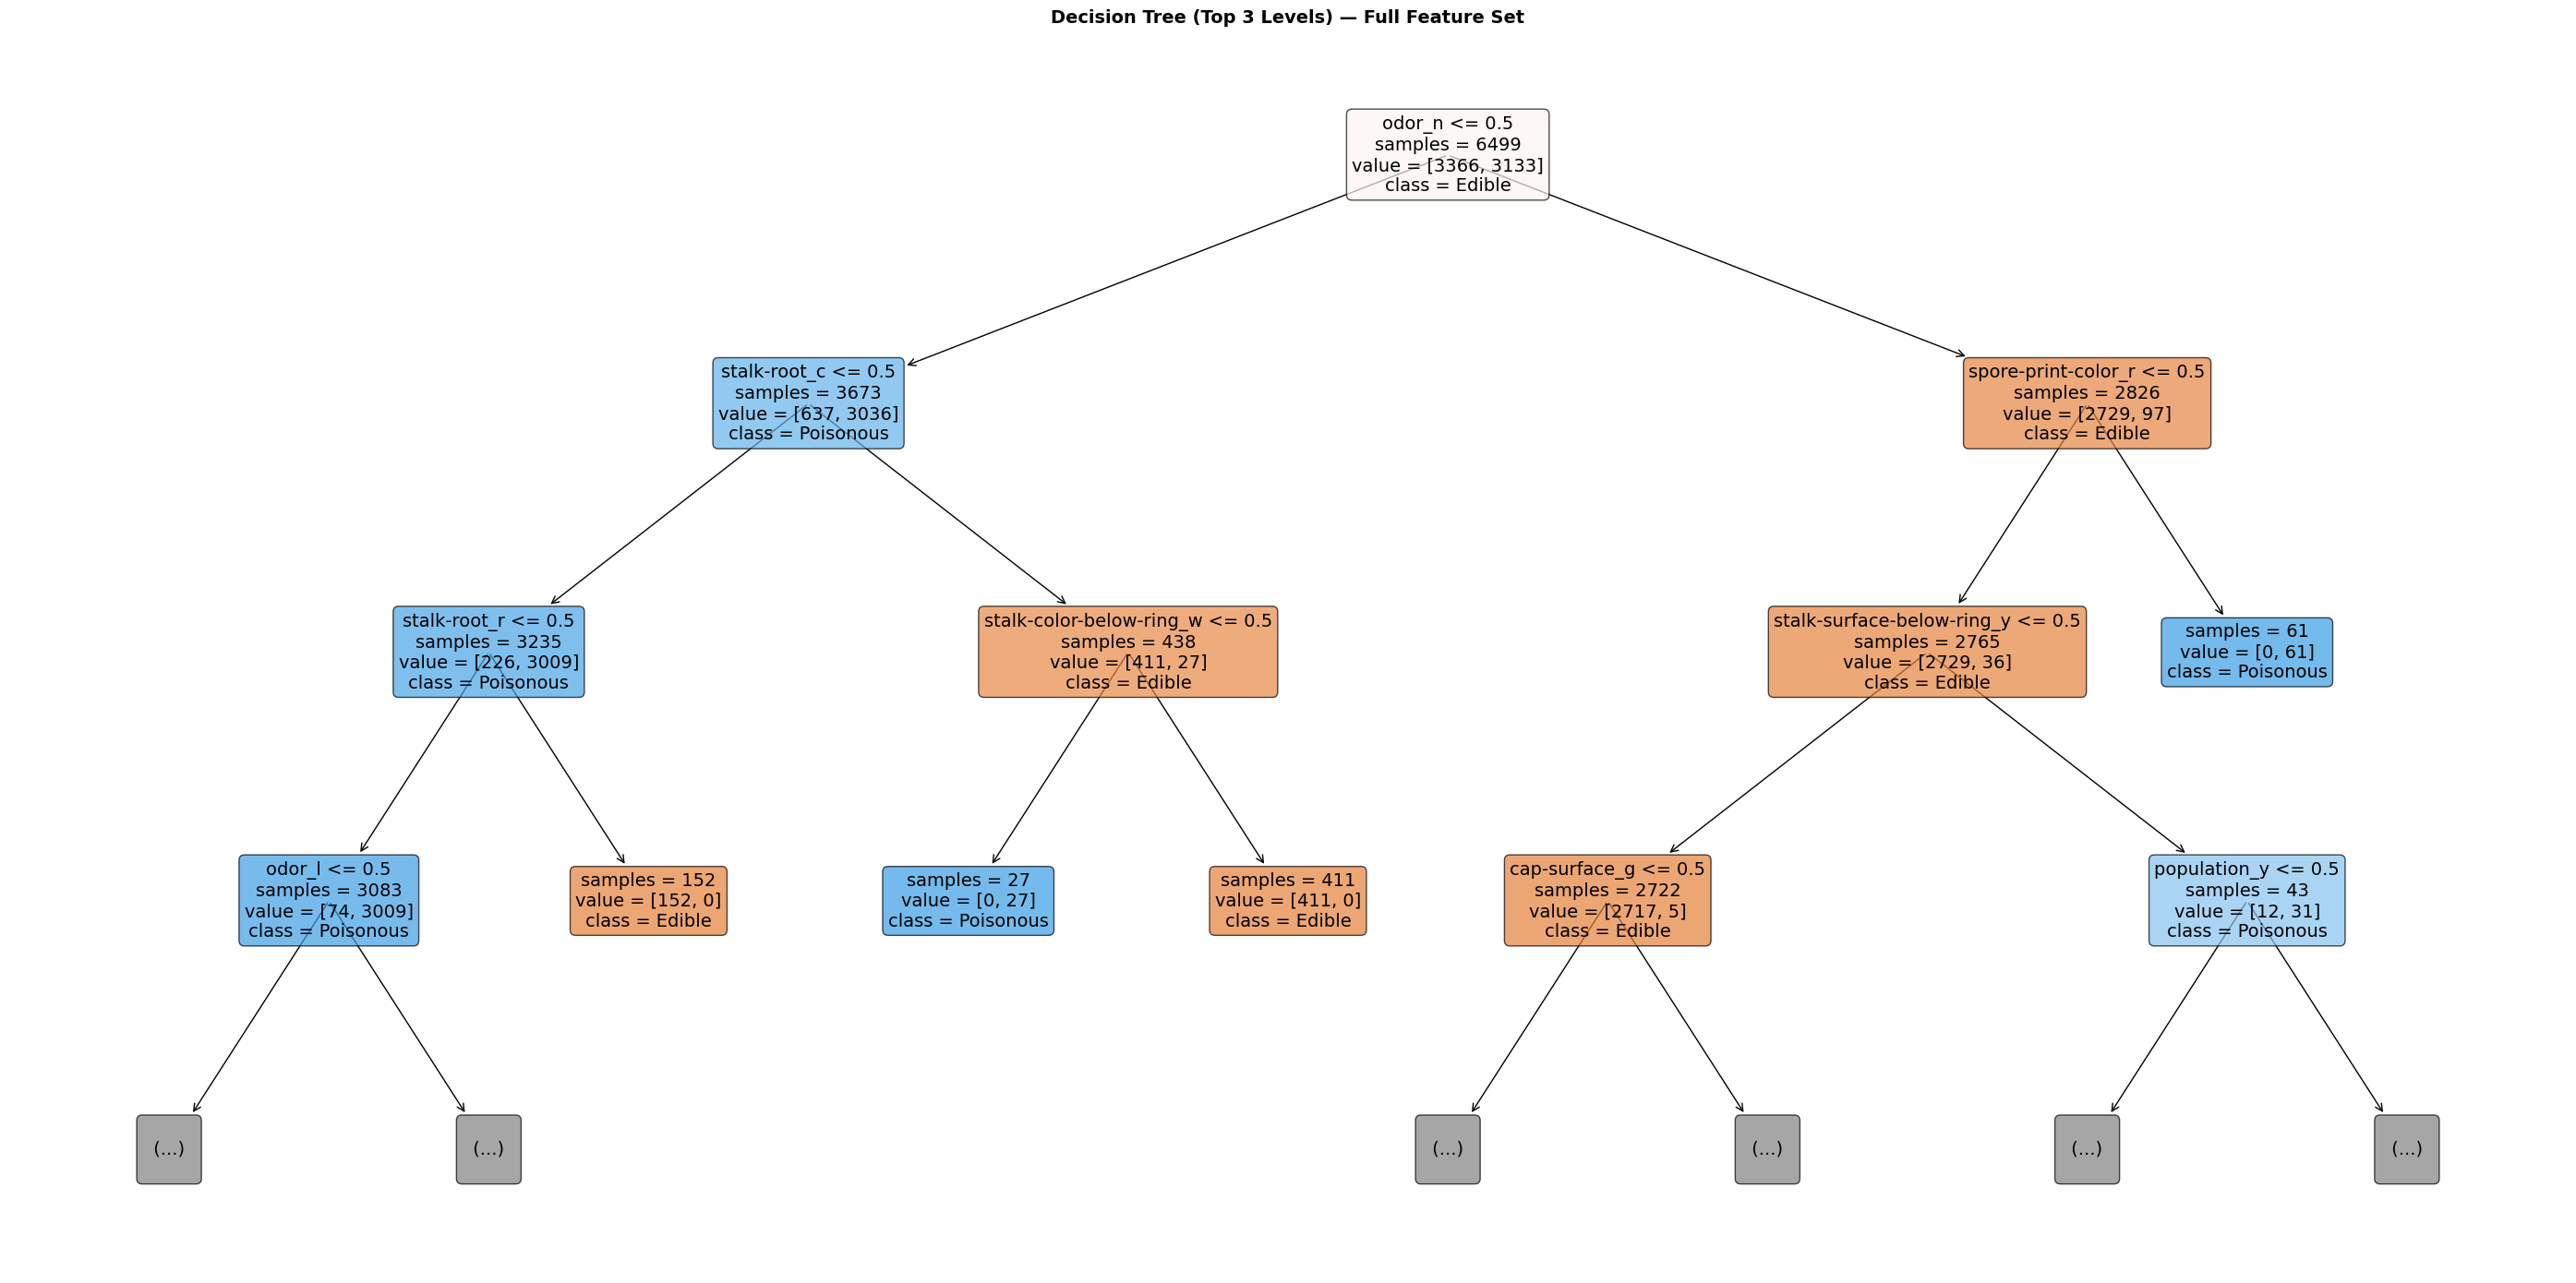

In [28]:
# --- TASK 6: VISUALIZE THE DECISION TREE ---
# We limit the displayed depth to 3 levels because the full tree is
# enormous and unreadable. The top 3 levels show the most important
# splits — exactly the decisions doing most of the classification work.

plt.figure(figsize=(28, 14))
artists = plot_tree(
    dt_full,
    max_depth=3,
    feature_names=X_mush.columns.tolist(),
    class_names=['Edible', 'Poisonous'],
    filled=True,
    rounded=True,
    fontsize=14,
    impurity=False
)

# Dial back the box color saturation so text stays readable
for artist in artists:
    artist.get_bbox_patch().set_alpha(0.7)   # 0.5 = half-strength color

plt.title('Decision Tree (Top 3 Levels) — Full Feature Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Section 8 Summary

The decision tree trained on all 95 features achieved a perfect 100% accuracy on the test set. Normally that would raise more than an eyebrow, but with the odor crosstab that we went in with it isn't that hard to believe. If you ever wanted to make yourself look like a genius, it seems that this is the dataset for you.  The physical features of the mushrooms are a dead give-away and the confusion matrix confirms this with zero off-diagonal entries - every edible mushroom was correctly identified, and every poisonous one was correctly flagged.

Our tree visualization (limited to the top 3 levels for readability) confirms what the EDA had already foreseen.  Right off the bat, the classifier splits first on `odor`, and then goes on to resolve most of the dataset. The remaining splits exist mostly to handle that `odor=none` edge case where 120 of the 3,528 mushrooms are still quite poisonous despite no detectable smell.

---
## Section 9: χ² Feature Selection — Top 5 Features

--- Top 5 Features Selected by χ² Test ---
  1. odor_f                              χ² score:    1884.44
  2. odor_n                              χ² score:    2269.14
  3. gill-size_n                         χ² score:    1281.07
  4. stalk-surface-above-ring_k          χ² score:    1606.34
  5. stalk-surface-below-ring_k          χ² score:    1537.11


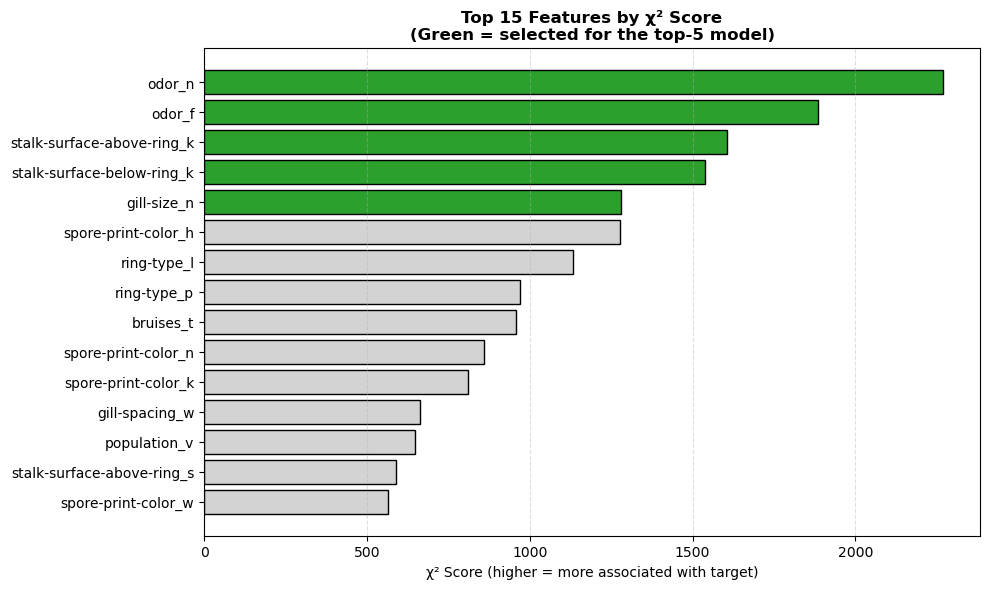

In [29]:
# --- TASK 7: SELECTKBEST WITH CHI-SQUARED ---
# The chi-squared (χ²) test measures the dependence between two categorical
# variables — perfect for our case where every feature AND the target are
# binary/categorical. SelectKBest picks the k features with the highest χ² scores.

selector = SelectKBest(score_func=chi2, k=5)
X_mush_train_top5 = selector.fit_transform(X_mush_train, y_mush_train)
X_mush_test_top5  = selector.transform(X_mush_test)

# --- TASK 8: WHICH FEATURES WERE SELECTED? ---
selected_mask     = selector.get_support()
selected_features = X_mush.columns[selected_mask].tolist()

feature_scores = pd.DataFrame({
    'Feature': X_mush.columns,
    'Chi2_Score': selector.scores_
}).sort_values('Chi2_Score', ascending=False).reset_index(drop=True)

print("--- Top 5 Features Selected by χ² Test ---")
for i, feat in enumerate(selected_features, start=1):
    score = feature_scores.loc[feature_scores['Feature']==feat, 'Chi2_Score'].values[0]
    print(f"  {i}. {feat:<35} χ² score: {score:>10.2f}")

fig, ax = plt.subplots(figsize=(10, 6))
top15 = feature_scores.head(15).sort_values('Chi2_Score')
colors = ['#2ca02c' if f in selected_features else 'lightgray' for f in top15['Feature']]
ax.barh(top15['Feature'], top15['Chi2_Score'], color=colors, edgecolor='black')
ax.set_title('Top 15 Features by χ² Score\n(Green = selected for the top-5 model)',
             fontweight='bold')
ax.set_xlabel('χ² Score (higher = more associated with target)')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

--- Decision Tree (Top 5 features only) ---
Test Accuracy: 97.60%

Classification Report:
              precision    recall  f1-score   support

      Edible       0.98      0.97      0.98       842
   Poisonous       0.97      0.98      0.98       783

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625



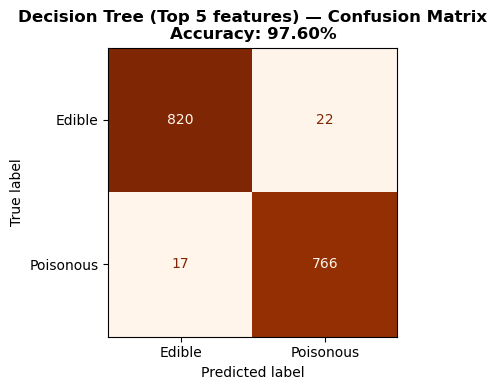

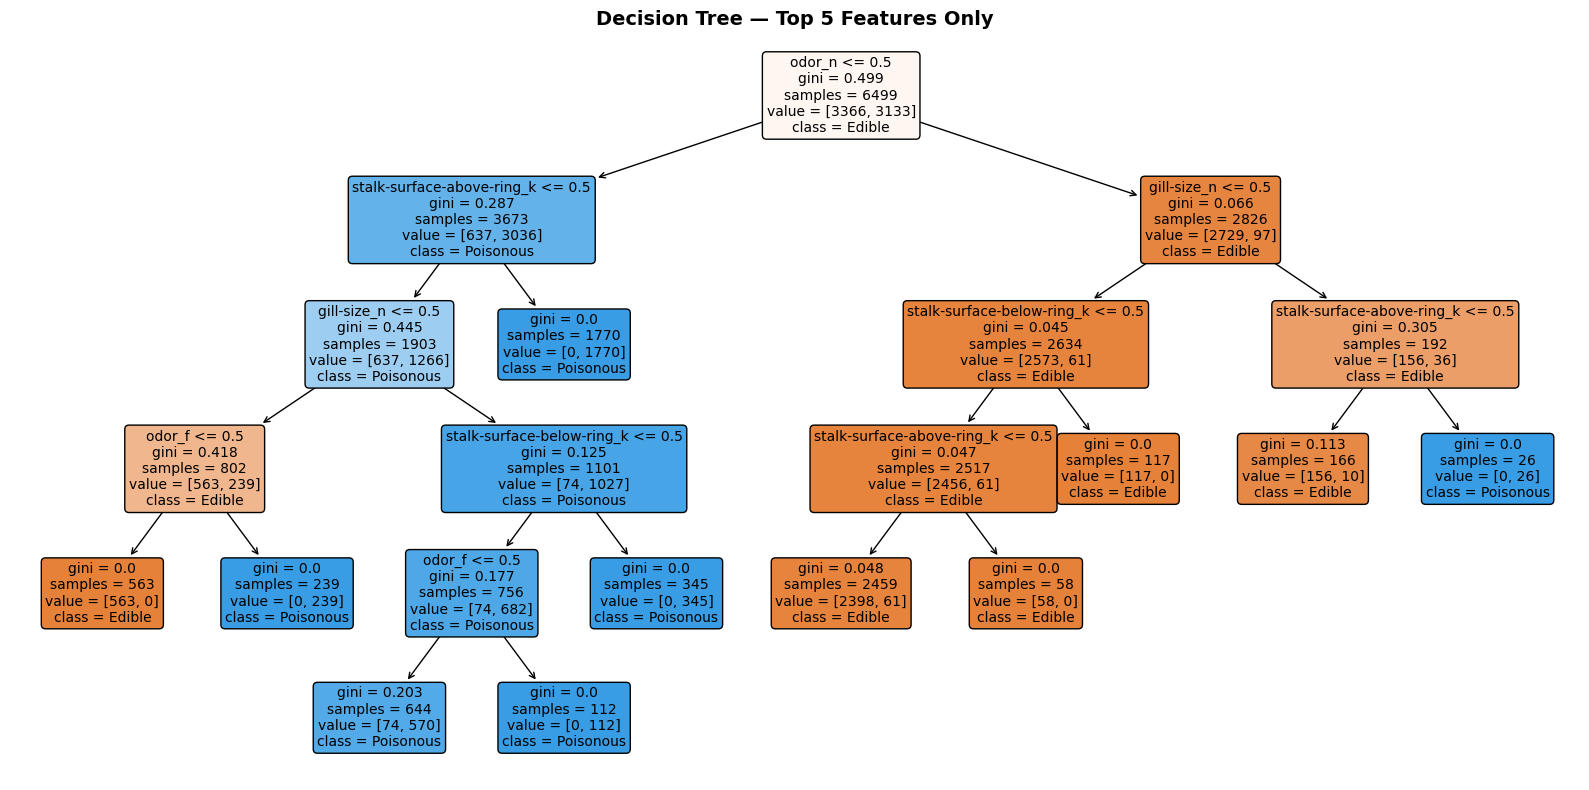

In [30]:
# --- TASK 9: TRAIN A NEW DECISION TREE WITH ONLY THE TOP 5 FEATURES ---
dt_top5 = DecisionTreeClassifier(random_state=42)
dt_top5.fit(X_mush_train_top5, y_mush_train)
y_pred_top5 = dt_top5.predict(X_mush_test_top5)

acc_top5 = accuracy_score(y_mush_test, y_pred_top5)
print(f"--- Decision Tree (Top 5 features only) ---")
print(f"Test Accuracy: {acc_top5*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_mush_test, y_pred_top5, target_names=['Edible', 'Poisonous']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_mush_test, y_pred_top5),
    display_labels=['Edible', 'Poisonous']
).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title(f'Decision Tree (Top 5 features) — Confusion Matrix\nAccuracy: {acc_top5*100:.2f}%',
             fontweight='bold')
plt.tight_layout()
plt.show()

# Visualize the smaller tree — easier to read with only 5 features
plt.figure(figsize=(16, 8))
plot_tree(
    dt_top5,
    feature_names=selected_features,
    class_names=['Edible', 'Poisonous'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree — Top 5 Features Only', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Part 2 Summary — Findings

The χ² feature selector hand-picked these five features as having the strongest statistical association with edibility:

1. `odor_f` — foul smell (a major poisonous indicator)
2. `odor_n` — no odor (a major edible indicator)
3. `gill-size_n` — narrow gills
4. `stalk-surface-above-ring_k` — silky surface above the ring
5. `stalk-surface-below-ring_k` — silky surface below the ring

Smell completely dominated the picture with two of the top five features being odor-related, and you can see the chi-squared scores for those two dwarf anything else in the dataset. The other three features describe stalk and gill structure, which serve as backup signals for the rare cases where odor isn't decisive on its own - those are the `odor=none` edge cases we identified during EDA.

**Performance comparison:**
- **Full model (95 features):** 100.00% accuracy
- **Top-5 model (5 features):** 97.60% accuracy

We dropped 95% of the features and only lost a meager 2.4 percentage points of accuracy. In a traditional machine learning context that's a fantastic tradeoff... the difference here is this dataset harbors some dire consequences - the cost of being wrong in this scenario could end up killing you, so even 2.4% misclassification is too high for our liking. 

---
## Final Conclusion

This week we got to play around with two related but distinct philosophies for working with fewer features.  Perhaps the most interesting thing we got to see first-hand was how preprocessing decisions shaped every single result. PCA went from being an utter disaster (1 component, R² 0.06) to being our best performer (127 components, R² 0.84) with a little help from a single `StandardScaler` call. Variance threshold filtering kept our standards high by cutting our housing features by 83% with virtually no accuracy loss because we min-max scaled first. And on the mushroom side, chi-squared selection picked 5 features out of 95 and only lost a measly 2.4 percentage points of accuracy — though in a scenario where being wrong means dying, even a measly amount is too much.

The diagnostic plots in Part 1 told a story that the metrics alone couldn't. An R² of 0.65 on the baseline looked unremarkable on paper, but a closer look at the predicted-vs-actual scatter and residual plot revealed the model was mostly failing with the high-end homes. That widening variance at higher prices is the kind of insight that thrusts you towards smarter feature engineering or a non-linear model.

Perhaps the biggest takeaway here is that process without preparation produces nonsense, no matter how shiny and sophisticated the algorithm. PCA looked like a dog in our lineup when it was mishandled, then turned out to be a unicorn when it was used properly. Variance threshold worked because min-max scaling came first. It's like painting your house... fancy tools can help make the job much easier, but if you don't grind out the prep work, it's going to look like hot garbage.  